In [2]:
import numpy as np
import pandas as pd

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
df= pd.read_csv("/content/drive/MyDrive/Celebal Technologies/Country-data.csv")
df.sample(5)

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
114,Norway,3.2,39.7,9.48,28.5,62300,5.95,81.0,1.95,87800
136,Solomon Islands,28.1,49.3,8.55,81.2,1780,6.81,61.7,4.24,1290
97,Mali,137.0,22.8,4.98,35.1,1870,4.37,59.5,6.55,708
92,"Macedonia, FYR",10.4,39.8,7.09,58.1,11400,2.04,74.0,1.47,4540
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460


Importing required libraries

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

Basic information about the dataset

In [6]:
print("Shape: ", df.shape)
df.info()
df.describe()

Shape:  (167, 10)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   country     167 non-null    object 
 1   child_mort  167 non-null    float64
 2   exports     167 non-null    float64
 3   health      167 non-null    float64
 4   imports     167 non-null    float64
 5   income      167 non-null    int64  
 6   inflation   167 non-null    float64
 7   life_expec  167 non-null    float64
 8   total_fer   167 non-null    float64
 9   gdpp        167 non-null    int64  
dtypes: float64(7), int64(2), object(1)
memory usage: 13.2+ KB


,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
count,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000
mean,38.270060,41.108976,6.815689,46.890215,17144.688623,7.781832,70.555689,2.947964,12964.155689
std,40.328931,27.412010,2.746837,24.209589,19278.067698,10.570704,8.893172,1.513848,18328.704809
min,2.600000,0.109000,1.810000,0.065900,609.000000,-4.210000,32.100000,1.150000,231.000000
25%,8.250000,23.800000,4.920000,30.200000,3355.000000,1.810000,65.300000,1.795000,1330.000000
50%,19.300000,35.000000,6.320000,43.300000,9960.000000,5.390000,73.100000,2.410000,4660.000000
75%,62.100000,51.350000,8.600000,58.750000,22800.000000,10.750000,76.800000,3.880000,14050.000000
max,208.000000,200.000000,17.900000,174.000000,125000.000000,104.000000,82.800000,7.490000,105000.000000


In [7]:
#the dataset doesnt have any null values.

In [8]:
#dropping the country column
countries= df['country']
df.drop('country', axis=1, inplace=True)

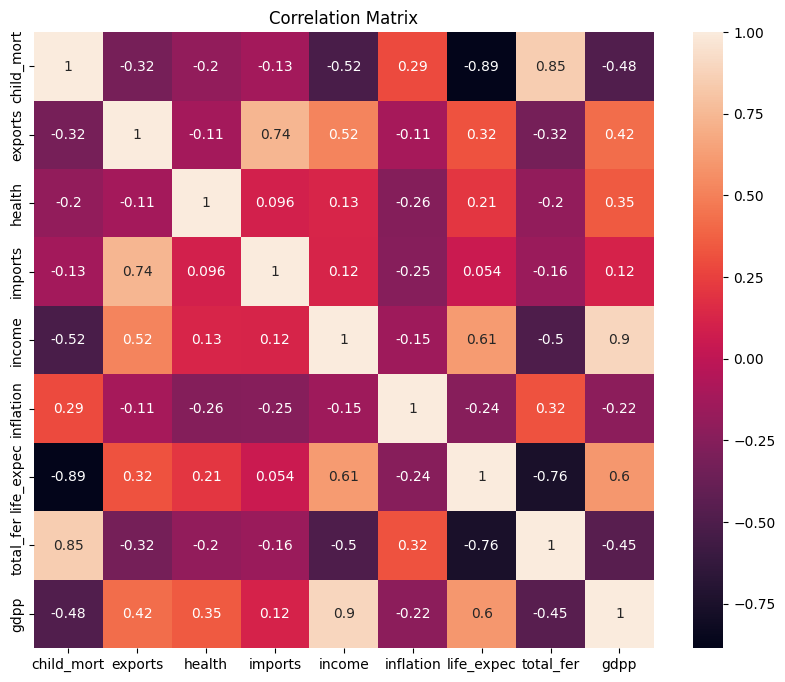

In [9]:
#creating the correlation heat map to identify the relation between the various columns
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True)
plt.title("Correlation Matrix")
plt.show()

In [10]:
# child_mort is related to total_fer
#income is related to gdpp

**Feature Scaling**

K-Means works best after scaling.

In [11]:
scaler= StandardScaler()
scaled_data= scaler.fit_transform(df)
scaled_data= pd.DataFrame(scaled_data, columns=df.columns)
scaled_data.sample(5)

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
34,-0.561332,-0.541862,-0.637438,-1.006348,-0.396180,-0.079878,0.456134,-0.899726,-0.459903
77,-0.872216,-0.955329,0.976525,-1.379219,0.970606,-0.918666,1.380962,-1.032237,1.725746
105,-0.118635,-0.325980,-0.589969,-0.161172,-0.556948,-0.645775,0.332071,-0.243797,-0.554575
110,-0.839884,1.130305,1.856536,0.692289,1.475282,-0.657921,1.144116,-0.767215,2.043141
154,0.590179,1.287642,-1.575873,-0.099027,-0.374849,-0.519198,-0.299519,-0.078158,-0.466470


**Finding Optimal number of clusters-Elbow Method**

In [12]:
wcss=[]
for k in range(1, 11):
  kmeans= KMeans(n_clusters=k, init='k-means++', random_state=42)
  kmeans.fit(scaled_data)
  wcss.append(kmeans.inertia_)

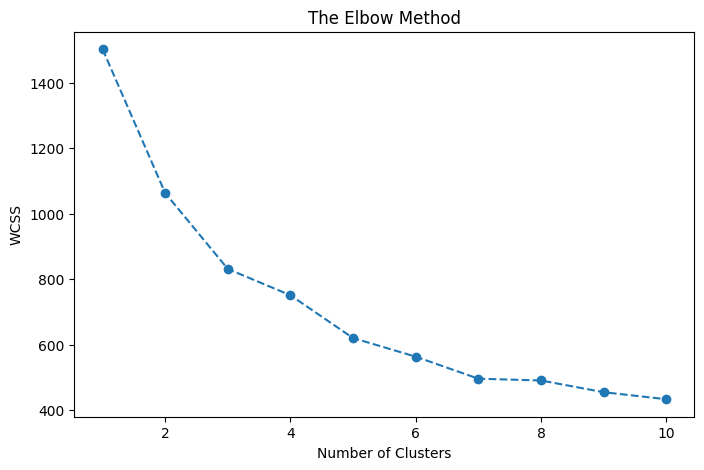

In [13]:
plt.figure(figsize=(8,5))
plt.plot(range(1,11), wcss, marker='o', linestyle='--')
plt.title("The Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.show()

### Optimal Number of Clusters

Based on the **Elbow Method** plot generated above, the optimal number of clusters appears to be **3**.

The 'elbow' in the plot, where the rate of decrease in the Within-Cluster Sum of Squares (WCSS) significantly slows down, is typically observed around K=3. This suggests that adding more clusters beyond three does not yield substantial improvements in explaining the variance in the data.

In [15]:
#Silhoutte Score
for k in range(2, 11):
  kmeans= KMeans(n_clusters=k, random_state=42, n_init= 10)
  labels= kmeans.fit_predict(scaled_data)
  score= silhouette_score(scaled_data, labels)
  print(f"K= {k}  --> Score = {score:.4f}")

K= 2  --> Score = 0.2874
K= 3  --> Score = 0.2833
K= 4  --> Score = 0.2960
K= 5  --> Score = 0.2993
K= 6  --> Score = 0.2287
K= 7  --> Score = 0.2477
K= 8  --> Score = 0.2388
K= 9  --> Score = 0.2073
K= 10  --> Score = 0.2022


We choose k=3 as the silhouette score differnece is not much and the elbow method suggests the best value to be 3.

**Training the final KMeans Model**

In [16]:
kmeans= KMeans(n_clusters= 3, random_state=42, n_init= 10)
clusters= kmeans.fit_predict(scaled_data)
scaled_data['Cluster']= clusters

In [23]:
# Adding back the country names
result= df.copy()
result['Country']= countries
result['Cluster']= clusters
result.head()

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp,Country,Cluster
0,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553,Afghanistan,1
1,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090,Albania,2
2,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460,Algeria,2
3,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530,Angola,1
4,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200,Antigua and Barbuda,2


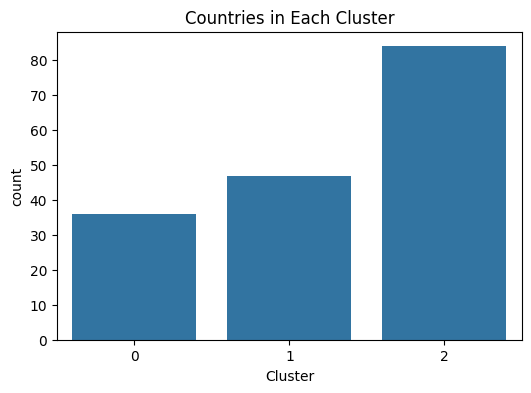

In [24]:
#Cluster Distribution
plt.figure(figsize=(6,4))
sns.countplot(x='Cluster', data= result)
plt.title("Countries in Each Cluster")
plt.show()

In [25]:
# PCA for 2D Visualization
pca= PCA(n_components=2)
pca_data= pca.fit_transform(scaled_data.drop('Cluster', axis=1))
pca_df= pd.DataFrame(pca_data, columns=['PC1', 'PC2'])
pca_df['Cluster']= clusters

<function matplotlib.pyplot.show(close=None, block=None)>

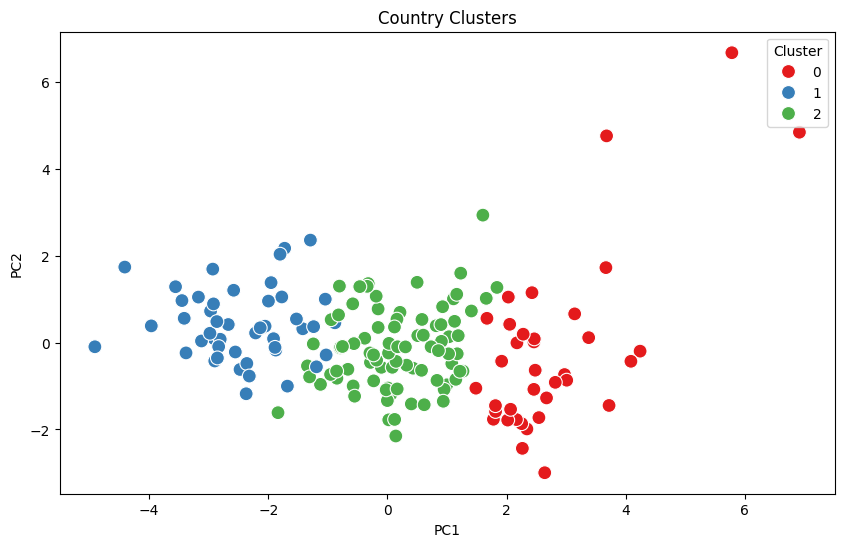

In [26]:
#visualize clusters
plt.figure(figsize=(10,6))
sns.scatterplot(x='PC1', y='PC2', hue='Cluster', data=pca_df, palette='Set1', s=100)
plt.title("Country Clusters")
plt.show

In [28]:
#cluster Centers
cluster_summary= result.drop('Country', axis=1).groupby('Cluster').mean()
cluster_summary

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
Cluster,,,,,,,,,
0,5.000000,58.738889,8.807778,51.491667,45672.222222,2.671250,80.127778,1.752778,42494.444444
1,92.961702,29.151277,6.388511,42.323404,3942.404255,12.019681,59.187234,5.008085,1922.382979
2,21.927381,40.243917,6.200952,47.473404,12305.595238,7.600905,72.814286,2.307500,6486.452381


In [29]:
#Understanding clusters
cluster_summary.T

Cluster,0,1,2
child_mort,5.000000,92.961702,21.927381
exports,58.738889,29.151277,40.243917
health,8.807778,6.388511,6.200952
imports,51.491667,42.323404,47.473404
income,45672.222222,3942.404255,12305.595238
inflation,2.671250,12.019681,7.600905
life_expec,80.127778,59.187234,72.814286
total_fer,1.752778,5.008085,2.307500
gdpp,42494.444444,1922.382979,6486.452381


In [30]:
cluster_summary[['income','gdpp','child_mort','life_expec']]

,income,gdpp,child_mort,life_expec
Cluster,,,,
0,45672.222222,42494.444444,5.000000,80.127778
1,3942.404255,1922.382979,92.961702,59.187234
2,12305.595238,6486.452381,21.927381,72.814286


The cluster having:

*   Lowest Income
*   Lowest GDP
*   Highest Child Mortality
*   Lowest Life Expectancy

is the target cluster.

So, our target cluster is Cluster 1.





In [31]:
target_cluster=1
needy_countries= result[result['Cluster']==target_cluster]
needy_countries.head()

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp,Country,Cluster
0,90.2,10.0,7.58,44.9,1610,9.440,56.2,5.82,553,Afghanistan,1
3,119.0,62.3,2.85,42.9,5900,22.400,60.1,6.16,3530,Angola,1
17,111.0,23.8,4.10,37.2,1820,0.885,61.8,5.36,758,Benin,1
21,52.5,43.6,8.30,51.3,13300,8.920,57.1,2.88,6350,Botswana,1
25,116.0,19.2,6.74,29.6,1430,6.810,57.9,5.87,575,Burkina Faso,1


In [32]:
#Ranking Countries by Severity
needy_countries['Priority_Score'] = (
    needy_countries['child_mort']
    + needy_countries['total_fer']
    - needy_countries['life_expec']
    - needy_countries['income']/1000
    - needy_countries['gdpp']/1000
)

needy_countries = needy_countries.sort_values(
    by='Priority_Score',
    ascending=False
)

needy_countries.head(20)

/tmp/ipykernel_577/1041107006.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  needy_countries['Priority_Score'] = (


,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp,Country,Cluster,Priority_Score
66,208.0,15.30,6.91,64.7,1500,5.450,32.1,3.33,662,Haiti,1,177.068
132,160.0,16.80,13.10,34.5,1220,17.200,55.0,5.20,399,Sierra Leone,1,108.581
31,149.0,11.80,3.98,26.5,888,2.010,47.5,5.21,446,Central African Republic,1,105.376
32,150.0,36.80,4.53,43.5,1930,6.390,56.5,6.59,897,Chad,1,97.263
97,137.0,22.80,4.98,35.1,1870,4.370,59.5,6.55,708,Mali,1,81.472
112,123.0,22.20,5.16,49.1,814,2.550,58.8,7.49,348,Niger,1,70.528
113,130.0,25.30,5.07,17.4,5150,104.000,60.5,5.84,2330,Nigeria,1,67.860
37,116.0,41.10,7.91,49.6,609,20.800,57.5,6.54,334,"Congo, Dem. Rep.",1,64.097
25,116.0,19.20,6.74,29.6,1430,6.810,57.9,5.87,575,Burkina Faso,1,61.965
64,114.0,14.90,8.50,35.2,1390,2.970,55.6,5.05,547,Guinea-Bissau,1,61.513


In [33]:
# Top 10 Countries for Aid
top10 = needy_countries.head(10)

print("Countries needing maximum aid:\n")

for country in top10['Country']:
    print(country)

Countries needing maximum aid:

Haiti
Sierra Leone
Central African Republic
Chad
Mali
Niger
Nigeria
Congo, Dem. Rep.
Burkina Faso
Guinea-Bissau


**Conclusion:**

1. Applied Standard Scaling on all socio-economic indicators.
2. Used Elbow Method and Silhouette Score to determine optimal clusters.
3. Performed K-Means clustering.
4. Visualized clusters using PCA.
5. Identified the underdeveloped cluster based on:
      - High Child Mortality
      - Low Income
      - Low GDP Per Capita
      - Low Life Expectancy
6. Ranked countries within the needy cluster.
7. Recommended the Top 10 countries for HELP International aid allocation.